# Prédiction des mouvements de fin de session du marché actions américain
## Challenge Data ENS – Challenge 84 *CFM*
### Master 2 IEF 2025/2026 – Machine Learning - Dhelia CHERIFI et Marie ABBYAD

# TO DO LIST

### 0. ok
### 1. ok
### 2. Commentaires sur le split etc
### 3. Toutes les stat desc -> Code + commentaires
### 4. Interprétation du modèle : les commentaires
### 5. Améliorer le commentaire sur les K-means + commentaires et analyse sur le meilleur modèle
### 6. interprétations
### 7. interprétations
### 8. interprétations
### 9. interprétations

## 0. Import des packages

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

# Sklearn - preprocessing & pipelines
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import (
    train_test_split, GridSearchCV, RandomizedSearchCV,
    TimeSeriesSplit, cross_val_score, StratifiedKFold
)

# Modèles de référence
from sklearn.linear_model import LogisticRegression, RidgeClassifier
from sklearn.dummy import DummyClassifier

# Arbre de décision
from sklearn.tree import DecisionTreeClassifier, plot_tree

# Méthodes ensemblistes
from sklearn.ensemble import (
    RandomForestClassifier, GradientBoostingClassifier,
    BaggingClassifier, AdaBoostClassifier, ExtraTreesClassifier,
    VotingClassifier
)
from sklearn.inspection import permutation_importance

# Clustering
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Métriques
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, f1_score,
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay
)

## 1. Présentation de la problématique et stratégie

### 1.1 Le challenge 84 : Prédiction des rendements de fin de session du marché américain par CFM

**Objectif** : prédire la classe `reod`, c'est-à-dire la **direction du mouvement de prix entre 14h et 16h** sur le marché actions américain, à partir de l'historique intraday observé entre **9h30 et 14h**.


### 1.2 Structure des données

Les données sont organisées de la sorte :

**Variables d'entrée** :
- `ID` : identifiant unique de la ligne ;
- `day` : identifiant du jour ;
- `equity` : identifiant de l'action ;
- `r0` à `r52` : rendements sur des fenêtres de **5 minutes** entre **9h30 et 14h00**.

**Variable cible** :
- `reod` : classe du rendement de fin de journée sur la fenêtre **14h00–16h00**. La cible est **multiclasse** à 3 modalités :

    - `-1` : baisse nette de plus de **25 bps** ;
    - `0` : variation modérée entre **-25 et +25 bps** ;
    - `1` : hausse nette de plus de **25 bps**.

    Avec la variation étant : $$\frac{P_{16h} - P_{14h}}{P_{14h}} * 10^4$$

### 1.3 Métrique d'évaluation

La métrique imposée par le challenge est l'**accuracy**. Comme il s'agit d'une classification à 3 classes, nous suivons aussi la **balanced accuracy** et le **macro-F1** pour mieux juger la qualité des modèles lorsque certaines classes sont moins fréquentes.

### 1.4 Stratégie

Notre stratégie est la suivante :
1. construire des features à partir de la trajectoire intraday `r0` à `r52` ;
2. utiliser un **split temporel par `day`** pour limiter le risque de fuite d'information ;
3. comparer plusieurs familles de modèles ;
4. ajouter un modèle non supervisé (K-Means) comme demandé dans la consigne ;
5. interpréter les résultats via les coefficients, l'importance des variables et SHAP quand disponible.

## 2. Chargement des données et split train / validation / test

### 2.1 Chargement des données

In [2]:
X_train_full = pd.read_csv("input_training.csv")
Y_train_full = pd.read_csv("output_training_gmEd6Zt.csv")
X_test_challenge = pd.read_csv("input_test.csv")

print("X_train shape :", X_train_full.shape)
print("Y_train shape :", Y_train_full.shape)
print("X_test  shape :", X_test_challenge.shape)

X_train shape : (843299, 56)
Y_train shape : (843299, 2)
X_test  shape : (885799, 56)


In [3]:
X_train_full.head(5)


,ID,day,equity,r0,r1,r2,r3,r4,r5,r6,...,r43,r44,r45,r46,r47,r48,r49,r50,r51,r52
0,0,249,1488,0.00,NaN,NaN,NaN,0.00,NaN,NaN,...,0.00,0.00,NaN,0.00,NaN,0.00,NaN,NaN,NaN,0.00
1,1,272,107,-9.76,0.00,-12.21,46.44,34.08,0.00,41.24,...,-4.83,-16.92,-4.84,4.84,0.00,7.26,-9.68,-19.38,9.71,26.68
2,2,323,1063,49.85,0.00,0.00,-26.64,-23.66,-22.14,49.12,...,-6.37,1.59,6.37,-49.32,-9.59,-6.40,22.41,-6.39,7.99,15.96
3,3,302,513,0.00,NaN,0.00,0.00,0.00,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.00,NaN
4,4,123,1465,-123.84,-115.18,-26.44,0.00,42.42,10.56,0.00,...,-5.36,-21.44,-21.48,10.78,-21.55,-5.40,-10.81,5.41,-32.47,43.43


In [4]:
Y_train_full.head(5)

,ID,reod
0,0,0
1,1,0
2,2,-1
3,3,0
4,4,-1


In [5]:
print("Proportion de -1, 0 et 0 dans Y_train : ")
print(Y_train_full["reod"].value_counts(normalize=True).sort_index().round(4))

Proportion de -1, 0 et 0 dans Y_train : 
reod
-1    0.3008
 0    0.4120
 1    0.2872
Name: proportion, dtype: float64


### 2.2 Split train / validation / test

In [6]:
df = X_train_full.merge(Y_train_full, on='ID')
print("Dataset complet :", df.shape)
print("Colonnes :", df.columns.tolist())

Dataset complet : (843299, 57)
Colonnes : ['ID', 'day', 'equity', 'r0', 'r1', 'r2', 'r3', 'r4', 'r5', 'r6', 'r7', 'r8', 'r9', 'r10', 'r11', 'r12', 'r13', 'r14', 'r15', 'r16', 'r17', 'r18', 'r19', 'r20', 'r21', 'r22', 'r23', 'r24', 'r25', 'r26', 'r27', 'r28', 'r29', 'r30', 'r31', 'r32', 'r33', 'r34', 'r35', 'r36', 'r37', 'r38', 'r39', 'r40', 'r41', 'r42', 'r43', 'r44', 'r45', 'r46', 'r47', 'r48', 'r49', 'r50', 'r51', 'r52', 'reod']


In [7]:
train_df, val_df = train_test_split(df, test_size=0.2, random_state=42, stratify=df['reod'])

print(f"Train : {len(train_df)} obs")
print(f"Val : {len(val_df)} obs")
print()
print("Distribution de train :")
print(train_df["reod"].value_counts(normalize=True).sort_index().round(4))
print()
print("Distribution de validation :")
print(val_df["reod"].value_counts(normalize=True).sort_index().round(4))

Train : 674639 obs
Val : 168660 obs

Distribution de train :
reod
-1    0.3008
 0    0.4120
 1    0.2872
Name: proportion, dtype: float64

Distribution de validation :
reod
-1    0.3008
 0    0.4120
 1    0.2872
Name: proportion, dtype: float64


Nous souhaitons garantir que train_df et val_df aient une proportion similaire de `-1`, `0` et `1` et utilisons ainsi stratify sur `reod`.

## 3. Construction des features 

### 3.1 Stratégie de construction des features

Nous avons des rendements toutes les 5 minutes et utiliserons ainsi les features suivantes :


derniers rendements observés (`r_last`, `r_last_3_mean`) 
moyenne cumulée sur le début, le milieu et la fin de matinée 
écart-type global, par blocs, amplitude max-min 
pente linéaire, skewness, kurtosis 
part de rendements positifs / négatifs 
moyenne par `day`, moyenne par `equity`, écart à la moyenne du jour 

In [8]:
def autocorr(x, lag=1):
    x = np.asarray(x, dtype=float)
    if len(x) <= lag or np.std(x) == 0:
        return 0.0
    return np.corrcoef(x[:-lag], x[lag:])[0, 1]


def compute_slope(arr):
    arr = np.asarray(arr, dtype=float)
    x = np.arange(len(arr))
    if np.std(arr) == 0:
        return 0.0
    return np.polyfit(x, arr, 1)[0]


def build_features(df):
    return_cols = sorted(
        [col for col in df.columns if col.startswith("r") and col[1:].isdigit()],
        key=lambda x: int(x[1:])
    )

    r = df[return_cols].copy()
    feats = pd.DataFrame(index=df.index)

    feats["ret_mean"] = r.mean(axis=1)
    feats["ret_std"] = r.std(axis=1)
    feats["ret_min"] = r.min(axis=1)
    feats["ret_max"] = r.max(axis=1)
    feats["max_minus_min"] = feats["ret_max"] - feats["ret_min"]

    half_len = len(return_cols) // 2
    feats["sum_first_half"] = r.iloc[:, :half_len].sum(axis=1)
    feats["sum_second_half"] = r.iloc[:, half_len:].sum(axis=1)
    feats["sum_diff_halves"] = feats["sum_second_half"] - feats["sum_first_half"]

    feats["mean_last_5_obs"] = r.iloc[:, -5:].mean(axis=1)
    feats["first_return_obs"] = r.iloc[:, 0]
    feats["last_return_obs"] = r.iloc[:, -1]
    feats["last_minus_first"] = feats["last_return_obs"] - feats["first_return_obs"]

    # Ici, on ne peut pas mettre r >, < ou = à 0 puique notre règle définie est >25bps, <-25bps
    # ou entre les deux, nous définissons donc positif, negatif ou mid par cette même règle
    feats["pos_ratio"] = (r > 25).mean(axis=1)
    feats["neg_ratio"] = (r < -25).mean(axis=1)
    feats["mid_ratio"] = ((r >= -25) & (r <= 25)).mean(axis=1)

    feats["ret_abs_mean"] = r.abs().mean(axis=1)

    feats["slope_all"] = r.apply(lambda row: compute_slope(row.values), axis=1)
    feats["autocorr_1"] = r.apply(lambda row: autocorr(row.values, lag=1), axis=1)

    signs = np.sign(r.values)
    feats["sign_changes"] = (signs[:, 1:] != signs[:, :-1]).sum(axis=1)

    return feats

In [9]:
train_feats = build_features(train_df)
val_feats = build_features(val_df)

X_train = train_feats
y_train = train_df["reod"]

X_val = val_feats
y_val = val_df["reod"]

### 3.2 Description statistique des features

In [10]:
feats_stats = X_train.describe().T
feats_stats["skew"] = X_train.skew()
feats_stats["kurtosis"] = X_train.kurtosis()

feats_stats

,count,mean,std,min,25%,50%,75%,max,skew,kurtosis
ret_mean,673027.0,31.973579,8039.843266,-1.965320e+03,-2.319245,-0.123019,1.689434,4.170943e+06,354.893212,151827.431219
ret_std,671129.0,265.144119,57929.445882,0.000000e+00,13.575348,20.484248,32.682197,3.036493e+07,361.815016,157555.945578
ret_min,673027.0,-101.203297,204.320583,-9.973540e+03,-93.460000,-54.950000,-33.560000,1.827200e+03,-9.245132,177.198823
ret_max,673027.0,1746.324147,417179.631825,-1.965320e+03,32.660000,53.040000,86.960000,2.210600e+08,368.903877,163350.002740
max_minus_min,673027.0,1847.527444,417179.479557,0.000000e+00,73.420000,115.030000,187.310000,2.210601e+08,368.903895,163350.050266
sum_first_half,674639.0,1640.563948,416791.126488,-1.988859e+04,-89.840000,-3.670000,67.230000,2.210600e+08,369.066683,163568.844511
sum_second_half,674639.0,-1.752883,107.927118,-3.452600e+03,-42.230000,0.000000,40.200000,6.631810e+03,1.521014,116.171451
sum_diff_halves,674639.0,-1642.316830,416791.108166,-2.210600e+08,-80.130000,3.750000,101.320000,1.991176e+04,-369.066693,163568.868310
mean_last_5_obs,643771.0,0.072325,12.104567,-9.909900e+02,-3.006000,0.000000,3.270000,1.168480e+03,-1.290259,547.081917
first_return_obs,638080.0,1406.478727,405023.053519,-9.967670e+03,-30.570000,0.000000,21.330000,2.210600e+08,405.960676,190710.080452


## DESCRIPTION STAT A FINIR : VOIR LES TP NOTAMMENT LABSESSION 2

## 4. Modèle de référence

### 4.1 Régression logistique

Notre variable objectif peut avoir trois valeurs (`-1`, `0` ou `1`) correspondant à un cas de **classification multi-classe**. Afin de construire un modèle simple de référence, nous faisons une régression logistique.

Nous commencons par mettre à l'échelle nos variables explicatives. En effet, certains features comme `ret_range` ou `last_minus_first` peuvent avoir des valeurs très élévées en valeur absolue (leur moyenne respective étant de 1847 et -1270) tandis que d'autres ont des valeurs bien plus faibles comme `pos_ratio`, `neg_ratio` et `mid_ratio` qui ont des valeurs comprises entre 0 et 1. Sans normalisation, les variables de plus grande amplitude domineraient artificiellement les autres dans l'apprentissage du modèle. Nous centrons et réduisons ainsi nos variables pour les rendre comparables entre elles.

En revanche, nous devons faire le fit_transform **uniquement** sur `train_df` et non sur `val_df` pour ne pas avoir de surapprentissage. Nous appliquons seulement le scalar de `train_df` sur `val_df`.

De plus, nous sommes en présence de NaN et imputons à ces valeurs la médiane de la feature. 

In [11]:
imputer = SimpleImputer(strategy="median")
scaler = StandardScaler()

train_imputed = imputer.fit_transform(X_train)
val_imputed = imputer.transform(X_val)

train_scaled = scaler.fit_transform(train_imputed)
val_scaled = scaler.transform(val_imputed)

In [12]:
logreg = LogisticRegression(
    C=0.1,
    solver='lbfgs',
    max_iter=500,
    class_weight='balanced',
    random_state=42
)

logreg.fit(train_scaled, y_train)

y_pred_logreg_base_train = logreg.predict(train_scaled)
y_pred_logreg_base_val = logreg.predict(val_scaled)

acc_train_logreg_base = accuracy_score(y_train, y_pred_logreg_base_train)
acc_val_logreg_base = accuracy_score(y_val, y_pred_logreg_base_val)

print(f'Accuracy train      : {acc_train_logreg_base:.4f}')
print(f'Accuracy val        : {acc_val_logreg_base:.4f}')
print(f'Écart train et val  : {acc_train_logreg_base - acc_val_logreg_base:.4f}')


Accuracy train      : 0.4578
Accuracy val        : 0.4586
Écart train et val  : -0.0009


Nous allons faire une sélection du meilleur paramètre C soit le paramètre de régularisation.

In [ ]:
logreg_cv_splitter = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

logreg_cv = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('logreg', LogisticRegression(solver='lbfgs', max_iter=500, class_weight='balanced', random_state=42))
])

param_grid_logreg = {'logreg__C': [0.001, 0.01, 0.1, 1.0, 10.0]}

grid_logreg = GridSearchCV(
    logreg_cv,
    param_grid_logreg,
    cv=logreg_cv_splitter,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_logreg.fit(train_feats, y_train)

print(f"Meilleur C : {grid_logreg.best_params_['logreg__C']}")
print(f"Meilleur score CV : {grid_logreg.best_score_:.4f}")

best_logreg = grid_logreg.best_estimator_
y_pred_best_logreg_train = best_logreg.predict(train_feats)
y_pred_best_logreg = best_logreg.predict(val_feats)

acc_train_logreg = accuracy_score(y_train, y_pred_best_logreg_train)
acc_logreg_best = accuracy_score(y_val, y_pred_best_logreg)
bacc_logreg_best = balanced_accuracy_score(y_val, y_pred_best_logreg)
f1_logreg_best = f1_score(y_val, y_pred_best_logreg, average='macro')

print(f'Accuracy train (meilleur C)      : {acc_train_logreg:.4f}')
print(f'Accuracy validation (meilleur C) : {acc_logreg_best:.4f}')
print(f'Balanced accuracy val            : {bacc_logreg_best:.4f}')
print(f'Macro-F1 val                     : {f1_logreg_best:.4f}')
print(f'Écart train et val               : {acc_train_logreg - acc_logreg_best:.4f}')


Fitting 5 folds for each of 5 candidates, totalling 25 fits
Meilleur C : 0.001
Meilleur score CV : 0.4577
Accuracy validation (meilleur C) : 0.4589
Écart train et val  : -0.0011


Nous obtenons le meilleur modèle pour un parmètre C = 0.001. 
Nous pouvons remarquer que l'accuracy du set de validation s'est en effet amélioré de 0.0003 en passant de 0.4586 pour C=0.1 à 0.4589. L'écart s'est donc légérement accentué puisque l'accuracy du train était légérement inférieure à celle de validation, l'écart est de -0.0011 ce qui reste très faible et indique que nous ne sommes pas dans un cas de surapprentissage. De plus, l'accuracy s'est améliorée, avec une autre seed nous pourrions avoir un résultat différent mais nous restons le bon ordre de grandeur ce qui est rassurant quant à notre modèle.

In [14]:
coef_abs = np.abs(best_logreg.named_steps['logreg'].coef_).mean(axis=0)
coef_df = pd.DataFrame({
    'feature': train_feats.columns,
    'coef_abs_mean': coef_abs
}).sort_values('coef_abs_mean', ascending=False).head(15)

coef_df

,feature,coef_abs_mean
14,mid_ratio,0.230936
13,neg_ratio,0.226317
12,pos_ratio,0.200883
18,sign_changes,0.014792
17,autocorr_1,0.008954
8,mean_last_5_obs,0.007037
6,sum_second_half,0.006834
11,last_minus_first,0.005754
16,slope_all,0.003261
15,ret_abs_mean,0.002623


## 5. Modèle non supervisé : K-Means

### 5.1 Objectif du clustering dans ce contexte

Le clustering ne prédit pas directement la cible `reod`, mais il permet :
1. d'identifier des **profils intraday** similaires ;
2. de vérifier si certains régimes de trajectoire `r0...r52` sont associés à davantage de baisses, de neutralité ou de hausses ;
3. de construire une feature de cluster réutilisable dans les modèles supervisés.

Nous commencons par préparer nos données en les standardisant pour les mêmes raisons que dans la partie précédente, nous le faisons afin d'éviter que certaines features dominent artificiellement les autres à cause de leur amplitude. Cela permet également de pouvoir comparer les features les unes avce les autres. 

In [ ]:
R_COLS = sorted([c for c in train_df.columns if c.startswith('r') and c[1:].isdigit()], key=lambda x: int(x[1:]))

X_cluster = train_df[R_COLS].fillna(0).values
print(f'Données de clustering : {X_cluster.shape}')

scaler_clust = StandardScaler()
X_cluster_scaled = scaler_clust.fit_transform(X_cluster)

Données de clustering : (674639, 53)


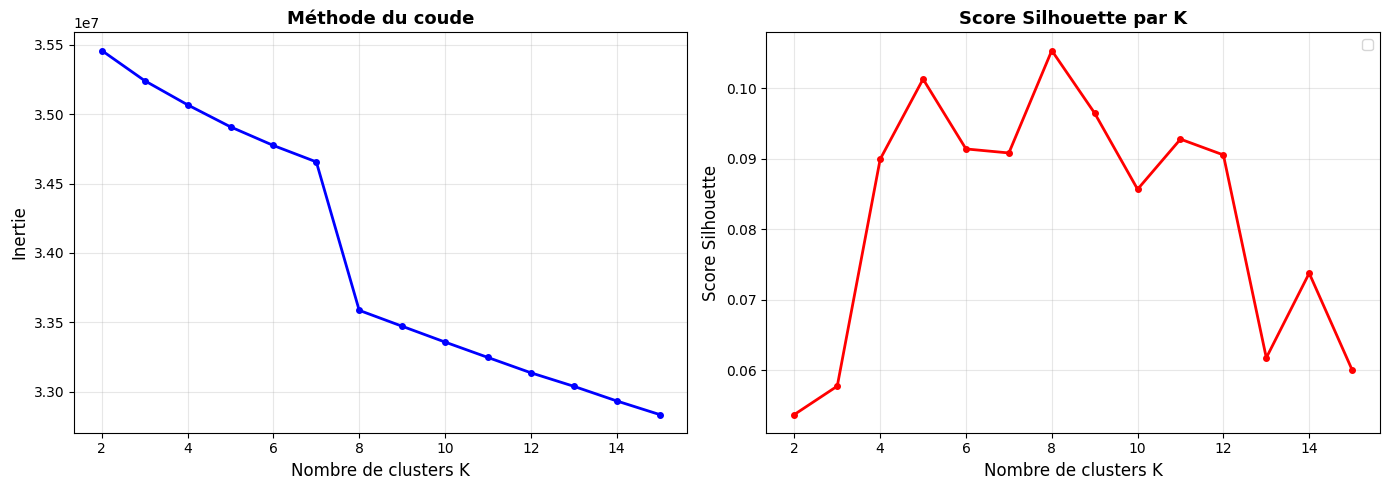

In [25]:
inertia = []
sil_scores = []
K_range = range(2, 16)

for k in K_range:
    km = KMeans(n_clusters=k, max_iter=300, random_state=42)
    km.fit(X_cluster_scaled)
    inertia.append(km.inertia_)
    sil_scores.append(silhouette_score(X_cluster_scaled, km.labels_, sample_size=5000, random_state=42))

# ─── Graphiques
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(list(K_range), inertia, 'b.-', linewidth=2, markersize=8)
axes[0].set_xlabel("Nombre de clusters K", fontsize=12)
axes[0].set_ylabel("Inertie", fontsize=12)
axes[0].set_title("Méthode du coude", fontsize=13, fontweight='bold')
axes[0].grid(True, alpha=0.3)

axes[1].plot(list(K_range), sil_scores, 'r.-', linewidth=2, markersize=8)
axes[1].set_xlabel("Nombre de clusters K", fontsize=12)
axes[1].set_ylabel("Score Silhouette", fontsize=12)
axes[1].set_title("Score Silhouette par K", fontsize=13, fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Les résultats obtenus indiquent pour la méthode du coude une cassure entre K = 7 et K = 8. Le graphique de silhouette nous indique ici un maximum global pour K = 8, ce qui est cohérent avec le graphique de la méthode du coude. En revanche, il est important de noter qu'au vu de la taille de nos données, nous avons pris un sous-échantillon pour le score silhouette ce qui permet de réduire drastiquement le temps d'exécution, pour stabiliser nos résultats, nous avons ajouter une seed également. 

In [28]:
K_OPTIMAL = 8

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    max_iter=500,
    random_state=42
)
kmeans_final.fit(X_cluster_scaled)

print(f"K-Means ajusté avec K={K_OPTIMAL}")
print(f"Inertie finale : {kmeans_final.inertia_:.2f}")

cluster_labels_train = kmeans_final.labels_
cluster_counts = pd.Series(cluster_labels_train).value_counts().sort_index()
print("\nNombre d'observations par cluster :")
print(cluster_counts.to_string())

K-Means ajusté avec K=8
Inertie finale : 33585929.65

Nombre d'observations par cluster :
0     66725
1     57340
2     47906
3     55412
4    385640
5         3
6     61611
7         2


Au vu du résultat de la silhouette, nous essayons pour K = 8, en revanche, nous obtenons deux clusters (5 et 7) avec 2 et 3 observations ce qui n'est pas proportionnel avec les autres clusters et bien trop peu donc inexploitable. Ainsi nous utiliserons K = 7 comme le préconise la règle du coude.

In [31]:
K_OPTIMAL = 7

kmeans_final = KMeans(
    n_clusters=K_OPTIMAL,
    max_iter=500,
    random_state=42
)
kmeans_final.fit(X_cluster_scaled)

print(f"K-Means ajusté avec K={K_OPTIMAL}")
print(f"Inertie finale : {kmeans_final.inertia_:.2f}")

cluster_labels_train = kmeans_final.labels_
cluster_counts = pd.Series(cluster_labels_train).value_counts().sort_index()
print("\nNombre d'observations par cluster :")
print(cluster_counts.to_string())

K-Means ajusté avec K=7
Inertie finale : 34655919.10

Nombre d'observations par cluster :
0     32725
1     68701
2     39718
3    377843
4     42904
5     53569
6     59179


Les clusters ont cette fois suffisament d'observations. 

Répartition des classes par cluster :
target       -1       0       1
cluster                        
0        0.3526  0.3049  0.3425
1        0.3394  0.3271  0.3334
2        0.3631  0.2866  0.3502
3        0.2635  0.4881  0.2484
4        0.3451  0.2941  0.3608
5        0.3590  0.3322  0.3088
6        0.3384  0.3262  0.3354


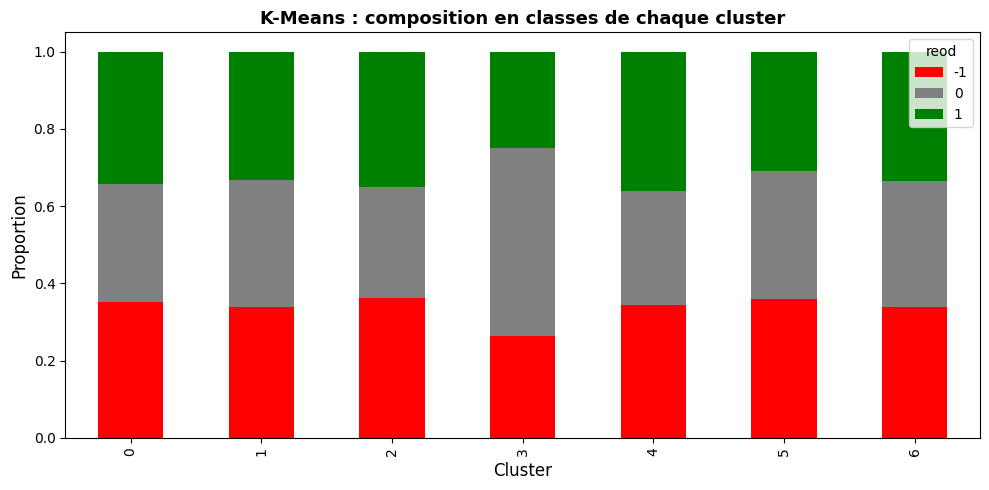

In [33]:
# ─────────────────────────────────────────────────────────────
# 5.5 Lien entre clusters et variable cible
# ─────────────────────────────────────────────────────────────
cluster_analysis = pd.DataFrame({
    'cluster': cluster_labels_train,
    'target':  y_train
})

cluster_stats = pd.crosstab(cluster_analysis['cluster'], cluster_analysis['target'], normalize='index')
cluster_stats = cluster_stats.reindex(columns=[-1, 0, 1], fill_value=0)
print('Répartition des classes par cluster :')
print(cluster_stats.round(4).to_string())

fig, ax = plt.subplots(figsize=(10, 5))
cluster_stats.plot(kind='bar', stacked=True, ax=ax, color=['red', 'gray', 'green'])
ax.set_xlabel('Cluster', fontsize=12)
ax.set_ylabel('Proportion', fontsize=12)
ax.set_title('K-Means : composition en classes de chaque cluster', fontsize=13, fontweight='bold')
ax.legend(title='reod')
plt.tight_layout()
plt.show()

In [40]:
# ─────────────────────────────────────────────────────────────
# 5.6 Features K-Means pour la logistique
# ─────────────────────────────────────────────────────────────
base_logistic_model = best_logreg
best_regularization_C = best_logreg.named_steps['logreg'].C


def build_cluster_feature_sets(train_features, val_features, train_dataframe, val_dataframe, return_columns, scaler, fitted_kmeans):
    train_returns = train_dataframe[return_columns].fillna(0).values
    val_returns = val_dataframe[return_columns].fillna(0).values

    train_returns_scaled = scaler.transform(train_returns)
    val_returns_scaled = scaler.transform(val_returns)

    train_cluster_labels = fitted_kmeans.predict(train_returns_scaled)
    val_cluster_labels = fitted_kmeans.predict(val_returns_scaled)

    train_cluster_distances = fitted_kmeans.transform(train_returns_scaled)
    val_cluster_distances = fitted_kmeans.transform(val_returns_scaled)

    # Variante 1: id de cluster brut
    train_with_cluster_id = train_features.copy()
    val_with_cluster_id = val_features.copy()
    train_with_cluster_id['kmeans_cluster_id'] = train_cluster_labels
    val_with_cluster_id['kmeans_cluster_id'] = val_cluster_labels

    # Variante 2: one-hot cluster
    train_cluster_onehot = pd.get_dummies(pd.Series(train_cluster_labels, name='cluster_label'), prefix='cluster')
    val_cluster_onehot = pd.get_dummies(pd.Series(val_cluster_labels, name='cluster_label'), prefix='cluster')
    train_cluster_onehot, val_cluster_onehot = train_cluster_onehot.align(val_cluster_onehot, axis=1, fill_value=0)

    train_with_cluster_onehot = pd.concat([train_features.reset_index(drop=True), train_cluster_onehot.reset_index(drop=True)], axis=1)
    val_with_cluster_onehot = pd.concat([val_features.reset_index(drop=True), val_cluster_onehot.reset_index(drop=True)], axis=1)

    # Variante 3: distances aux centroïdes
    n_clusters = train_cluster_distances.shape[1]
    distance_column_names = [f'cluster_distance_{cluster_index}' for cluster_index in range(n_clusters)]

    train_distance_features = pd.DataFrame(train_cluster_distances, columns=distance_column_names)
    val_distance_features = pd.DataFrame(val_cluster_distances, columns=distance_column_names)

    train_with_cluster_distances = pd.concat([train_features.reset_index(drop=True), train_distance_features], axis=1)
    val_with_cluster_distances = pd.concat([val_features.reset_index(drop=True), val_distance_features], axis=1)

    # Variante 4: one-hot + distances
    train_with_onehot_and_distances = pd.concat([train_with_cluster_onehot, train_distance_features], axis=1)
    val_with_onehot_and_distances = pd.concat([val_with_cluster_onehot, val_distance_features], axis=1)

    return {
        'Logistique + cluster_id': (train_with_cluster_id, val_with_cluster_id),
        'Logistique + cluster_onehot': (train_with_cluster_onehot, val_with_cluster_onehot),
        'Logistique + cluster_distances': (train_with_cluster_distances, val_with_cluster_distances),
        'Logistique + onehot + distances': (train_with_onehot_and_distances, val_with_onehot_and_distances),
    }


cluster_feature_sets = build_cluster_feature_sets(
    train_features=train_feats,
    val_features=val_feats,
    train_dataframe=train_df,
    val_dataframe=val_df,
    return_columns=R_COLS,
    scaler=scaler_clust,
    fitted_kmeans=kmeans_final,
)


Base (sans cluster)
  Accuracy train : 0.4580
  Accuracy val   : 0.4589

Meilleure variante avec cluster
  Modèle         : Logistique + onehot + distances
  Accuracy train : 0.4607
  Accuracy val   : 0.4617


In [ ]:
# ─────────────────────────────────────────────────────────────
# 5.6 bis Entraînement et comparaison des variantes
# ─────────────────────────────────────────────────────────────
def compute_metrics(y_train_true, y_train_pred, y_val_true, y_val_pred):
    return {
        'acc_train': accuracy_score(y_train_true, y_train_pred),
        'acc_val': accuracy_score(y_val_true, y_val_pred),
        'bacc_val': balanced_accuracy_score(y_val_true, y_val_pred),
        'f1_val': f1_score(y_val_true, y_val_pred, average='macro'),
    }


def fit_logistic_pipeline(train_matrix, y_train_labels, regularization_C):
    model = Pipeline([
        ('imputer', SimpleImputer(strategy='median')),
        ('scaler', StandardScaler()),
        ('logreg', LogisticRegression(
            C=regularization_C,
            solver='lbfgs',
            max_iter=500,
            class_weight='balanced',
            random_state=42,
        )),
    ])
    model.fit(train_matrix, y_train_labels)
    return model


# Référence: logistique sans cluster (déjà entraînée)
base_train_predictions = base_logistic_model.predict(train_feats)
base_val_predictions = base_logistic_model.predict(val_feats)
base_logistic_results = compute_metrics(y_train, base_train_predictions, y_val, base_val_predictions)

variant_models = {}
variant_results = {}
for variant_name, (train_variant_matrix, val_variant_matrix) in cluster_feature_sets.items():
    variant_model = fit_logistic_pipeline(train_variant_matrix, y_train, best_regularization_C)
    train_predictions = variant_model.predict(train_variant_matrix)
    val_predictions = variant_model.predict(val_variant_matrix)

    variant_models[variant_name] = variant_model
    variant_results[variant_name] = compute_metrics(y_train, train_predictions, y_val, val_predictions)

best_variant_name = max(variant_results, key=lambda variant: variant_results[variant]['acc_val'])
best_logreg_cluster = variant_models[best_variant_name]
results_logreg_cluster = variant_results[best_variant_name]
results_logreg_base = base_logistic_results

print('Base (sans cluster)')
print(f"  Accuracy train : {base_logistic_results['acc_train']:.4f}")
print(f"  Accuracy val   : {base_logistic_results['acc_val']:.4f}")
print()
print('Meilleure variante avec cluster')
print(f'  Modèle         : {best_variant_name}')
print(f"  Accuracy train : {results_logreg_cluster['acc_train']:.4f}")
print(f"  Accuracy val   : {results_logreg_cluster['acc_val']:.4f}")


In [41]:
# ─────────────────────────────────────────────────────────────
# 5.7 Comparaison synthétique des variantes
# ─────────────────────────────────────────────────────────────
comparison_rows = [
    {
        'Modele': 'Logistique seule',
        'Acc_train': results_logreg_base['acc_train'],
        'Acc_val': results_logreg_base['acc_val'],
        'BAcc_val': results_logreg_base['bacc_val'],
        'F1_val': results_logreg_base['f1_val'],
    }
]

for variant_name, variant_metrics in variant_results.items():
    comparison_rows.append({
        'Modele': variant_name,
        'Acc_train': variant_metrics['acc_train'],
        'Acc_val': variant_metrics['acc_val'],
        'BAcc_val': variant_metrics['bacc_val'],
        'F1_val': variant_metrics['f1_val'],
    })

comparison_df = pd.DataFrame(comparison_rows)
comparison_df['Delta_Acc_val_vs_base'] = comparison_df['Acc_val'] - results_logreg_base['acc_val']
comparison_df = comparison_df.sort_values(['Acc_val', 'F1_val'], ascending=False).reset_index(drop=True)
comparison_df


,Modele,Acc_train,Acc_val,Delta_Acc_val_vs_base
0,Logistique + onehot + distances,0.460747,0.461704,0.002828
1,Logistique + cluster_onehot,0.460042,0.461431,0.002555
2,Logistique + cluster_distances,0.459844,0.460951,0.002075
3,Logistique seule,0.457968,0.458876,0.000000
4,Logistique + cluster_id,0.457609,0.458858,-0.000018


## 6. Modèles supervisés ensemblistes

### 6.1 Random Forest

Le Random Forest est une méthode ensembliste basée sur le **bagging** d'arbres de décision. Chaque arbre est entraîné sur un sous-échantillon aléatoire des données et des features (`max_features='sqrt'`), ce qui réduit la corrélation entre arbres et améliore la généralisation.


In [42]:
rf_base = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    min_samples_split=100,
    min_samples_leaf=50,
    max_features='sqrt',
    class_weight='balanced',
    oob_score=True,
    n_jobs=-1,
    random_state=42
)

rf_base.fit(X_train, y_train)

y_pred_rf = rf_base.predict(X_val)
acc_rf = accuracy_score(y_val, y_pred_rf)
bacc_rf = balanced_accuracy_score(y_val, y_pred_rf)
f1_rf = f1_score(y_val, y_pred_rf, average='macro')
acc_oob = rf_base.oob_score_
acc_train_rf = accuracy_score(y_train, rf_base.predict(X_train))

print('Random Forest (base)')
print(f'  OOB score            : {acc_oob:.4f}')
print(f'  Accuracy train       : {acc_train_rf:.4f}')
print(f'  Accuracy val         : {acc_rf:.4f}')
print(f'  Balanced accuracy val: {bacc_rf:.4f}')
print(f'  Macro-F1 val         : {f1_rf:.4f}')
print(f'  Écart train/val      : {acc_train_rf - acc_rf:.4f}')


Random Forest (base)
  OOB score            : 0.4576
  Accuracy train       : 0.4643
  Accuracy val         : 0.4571
  Écart train/val      : 0.0072


In [ ]:
# ─────────────────────────────────────────────────────────────
# 6.1.2 Random Forest – tuning équilibré (qualité/temps)
# ─────────────────────────────────────────────────────────────
rf_cv_splitter = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

max_tuning_samples = 150_000
if len(X_train) > max_tuning_samples:
    sampled_row_positions = np.random.RandomState(42).choice(len(X_train), size=max_tuning_samples, replace=False)

    if isinstance(X_train, pd.DataFrame):
        X_tune = X_train.iloc[sampled_row_positions]
    else:
        X_tune = X_train[sampled_row_positions]

    if isinstance(y_train, pd.Series):
        y_tune = y_train.iloc[sampled_row_positions]
    else:
        y_tune = y_train[sampled_row_positions]
else:
    X_tune = X_train
    y_tune = y_train

param_grid_rf = {
    'n_estimators': [180, 260, 340],
    'max_depth': [10, 14, None],
    'min_samples_split': [20, 50, 100],
    'min_samples_leaf': [10, 30, 60],
    'max_features': ['sqrt', 0.5],
    'max_samples': [0.6, 0.8, None],
    'class_weight': [None, 'balanced'],
}

rf_grid_search = RandomizedSearchCV(
    estimator=RandomForestClassifier(
        bootstrap=True,
        oob_score=False,
        n_jobs=1,
        random_state=42
    ),
    param_distributions=param_grid_rf,
    n_iter=16,
    cv=rf_cv_splitter,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print(
    f"RandomizedSearchCV RF ({rf_grid_search.n_iter} combinaisons × "
    f"{rf_cv_splitter.get_n_splits()} folds) sur {len(X_tune):,} lignes..."
)
rf_grid_search.fit(X_tune, y_tune)

print('')
print('Meilleurs paramètres (tuning):')
for key, value in rf_grid_search.best_params_.items():
    print(f"  {key}: {value}")
print(f"Meilleur score CV (tuning): {rf_grid_search.best_score_:.4f}")

best_rf = RandomForestClassifier(
    **rf_grid_search.best_params_,
    bootstrap=True,
    oob_score=False,
    n_jobs=-1,
    random_state=42
)
best_rf.fit(X_train, y_train)

y_pred_best_rf_train = best_rf.predict(X_train)
y_pred_best_rf_val = best_rf.predict(X_val)

acc_train_best_rf = accuracy_score(y_train, y_pred_best_rf_train)
acc_val_best_rf = accuracy_score(y_val, y_pred_best_rf_val)
bacc_val_best_rf = balanced_accuracy_score(y_val, y_pred_best_rf_val)
f1_val_best_rf = f1_score(y_val, y_pred_best_rf_val, average='macro')

print('')
print('Random Forest optimisé (refit full train)')
print(f"  Accuracy train       : {acc_train_best_rf:.4f}")
print(f"  Accuracy val         : {acc_val_best_rf:.4f}")
print(f"  Balanced accuracy val: {bacc_val_best_rf:.4f}")
print(f"  Macro-F1 val         : {f1_val_best_rf:.4f}")
print(f"  Écart train/val      : {acc_train_best_rf - acc_val_best_rf:.4f}")


RandomizedSearchCV RF (16 combinaisons × 3 folds) sur 150,000 lignes...
Fitting 3 folds for each of 16 candidates, totalling 48 fits

Meilleurs paramètres (tuning):
  n_estimators: 260
  min_samples_split: 100
  min_samples_leaf: 10
  max_samples: 0.8
  max_features: 0.5
  max_depth: 14
  class_weight: None
Meilleur score CV (tuning): 0.4699


In [48]:
# ─────────────────────────────────────────────────────────────
# Comparaison directe : Random Forest vs Régression logistique
# ─────────────────────────────────────────────────────────────
def compute_model_metrics(y_train_true, y_train_pred, y_val_true, y_val_pred):
    return {
        'Accuracy_train': accuracy_score(y_train_true, y_train_pred),
        'Accuracy_val': accuracy_score(y_val_true, y_val_pred),
        'BalancedAccuracy_val': balanced_accuracy_score(y_val_true, y_val_pred),
        'MacroF1_val': f1_score(y_val_true, y_val_pred, average='macro')
    }

# Prédictions RF
rf_train_pred = best_rf.predict(X_train)
rf_val_pred = best_rf.predict(X_val)
rf_metrics = compute_model_metrics(y_train, rf_train_pred, y_val, rf_val_pred)

# Prédictions logistique (modèle de référence de la partie 4)
logreg_train_pred = best_logreg.predict(train_feats)
logreg_val_pred = best_logreg.predict(val_feats)
logreg_metrics = compute_model_metrics(y_train, logreg_train_pred, y_val, logreg_val_pred)

comparison_models_df = pd.DataFrame([
    {'Modele': 'Régression logistique', **logreg_metrics},
    {'Modele': 'Random Forest', **rf_metrics},
]).sort_values('Accuracy_val', ascending=False).reset_index(drop=True)

comparison_models_df['Delta_Accuracy_val_vs_logreg'] = (
    comparison_models_df['Accuracy_val'] - logreg_metrics['Accuracy_val']
)

print('Comparaison modèles (validation prioritaire)')
print(comparison_models_df.round(4).to_string(index=False))


Comparaison modèles (validation prioritaire)
               Modele  Accuracy_train  Accuracy_val  BalancedAccuracy_val  MacroF1_val  Delta_Accuracy_val_vs_logreg
        Random Forest          0.5188        0.4716                0.4339       0.4138                        0.0127
Régression logistique          0.4580        0.4589                0.4338       0.4280                        0.0000


### 6.2 Gradient Boosting (sklearn)

In [49]:
# ─────────────────────────────────────────────────────────────
# 6.2.1 Gradient Boosting – version de base avec early stopping
# Le Gradient Boosting construit les arbres séquentiellement,
# chaque arbre corrigeant les erreurs du précédent.
# ─────────────────────────────────────────────────────────────
from sklearn.ensemble import HistGradientBoostingClassifier

# On utilise HistGradientBoostingClassifier (bien plus rapide que GBC standard)
# sur de grands datasets, et supporte nativement les NaN.
hgb = HistGradientBoostingClassifier(
    max_iter=300,                # nombre maximal d'itérations (arbres)
    learning_rate=0.05,          # taux d'apprentissage faible → meilleure généralisation
    max_depth=6,                 # profondeur max de chaque arbre
    min_samples_leaf=50,         # régularisation
    l2_regularization=0.1,       # régularisation L2 sur les feuilles
    early_stopping=True,         # arrêt anticipé sur la validation interne
    validation_fraction=0.1,     # 10% du train pour early stopping
    n_iter_no_change=20,         # patience pour early stopping
    random_state=42,
    verbose=1
)

print("Entraînement Hist Gradient Boosting (avec early stopping)...")
hgb.fit(X_train, y_train)
print(f"Nombre d'arbres utilisés : {hgb.n_iter_}")


Entraînement Hist Gradient Boosting (avec early stopping)...
Binning 0.092 GB of training data: 0.185 s
Binning 0.010 GB of validation data: 0.011 s
Fitting gradient boosted rounds:
Fit 495 trees in 7.610 s, (15160 total leaves)
Time spent computing histograms: 3.201s
Time spent finding best splits:  0.461s
Time spent applying splits:      1.494s
Time spent predicting:           0.236s
Nombre d'arbres utilisés : 165


In [50]:
y_pred_hgb = hgb.predict(X_val)

acc_train_hgb = accuracy_score(y_train, hgb.predict(X_train))
acc_val_hgb   = accuracy_score(y_val, y_pred_hgb)
bacc_val_hgb  = balanced_accuracy_score(y_val, y_pred_hgb)
f1_val_hgb    = f1_score(y_val, y_pred_hgb, average='macro')

print('Hist Gradient Boosting')
print(f'  Accuracy train       : {acc_train_hgb:.4f}')
print(f'  Accuracy val         : {acc_val_hgb:.4f}')
print(f'  Balanced accuracy val: {bacc_val_hgb:.4f}')
print(f'  Macro-F1 val         : {f1_val_hgb:.4f}')
print(f'  Écart                : {acc_train_hgb - acc_val_hgb:.4f}')
print()
print(classification_report(y_val, y_pred_hgb, labels=[-1, 0, 1], target_names=['Baisse', 'Neutre', 'Hausse']))

Hist Gradient Boosting
  Accuracy train       : 0.4863
  Accuracy val         : 0.4709
  Balanced accuracy val: 0.4334
  Macro-F1 val         : 0.4166
  Écart                : 0.0154

              precision    recall  f1-score   support

      Baisse       0.38      0.38      0.38     50728
      Neutre       0.53      0.74      0.62     69493
      Hausse       0.40      0.18      0.25     48439

    accuracy                           0.47    168660
   macro avg       0.44      0.43      0.42    168660
weighted avg       0.45      0.47      0.44    168660



In [ ]:
# ─────────────────────────────────────────────────────────────
# 6.2.2 Tuning HistGradientBoosting
# ─────────────────────────────────────────────────────────────
# CV locale pour éviter la dépendance à une cellule précédente
hgb_cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

# Sous-échantillon pour accélérer le tuning
max_hgb_tuning_samples = 150_000
if len(X_train) > max_hgb_tuning_samples:
    sampled_row_positions_hgb = np.random.RandomState(42).choice(len(X_train), size=max_hgb_tuning_samples, replace=False)

    if isinstance(X_train, pd.DataFrame):
        X_tune_hgb = X_train.iloc[sampled_row_positions_hgb]
    else:
        X_tune_hgb = X_train[sampled_row_positions_hgb]

    if isinstance(y_train, pd.Series):
        y_tune_hgb = y_train.iloc[sampled_row_positions_hgb]
    else:
        y_tune_hgb = y_train[sampled_row_positions_hgb]
else:
    X_tune_hgb = X_train
    y_tune_hgb = y_train

param_grid_hgb = {
    'learning_rate': [0.03, 0.05, 0.1],
    'max_depth': [4, 6, 8],
    'min_samples_leaf': [30, 50, 100],
    'l2_regularization': [0.01, 0.1, 1.0],
    'max_leaf_nodes': [15, 31, 63],
}

hgb_search = RandomizedSearchCV(
    HistGradientBoostingClassifier(
        max_iter=300,
        early_stopping=False,  # important: pas de validation interne pendant la CV
        random_state=42
    ),
    param_distributions=param_grid_hgb,
    n_iter=16,
    cv=hgb_cv,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

print(
    f"RandomizedSearchCV HGB ({hgb_search.n_iter} combinaisons × "
    f"{hgb_cv.get_n_splits()} folds) sur {len(X_tune_hgb):,} lignes..."
)
hgb_search.fit(X_tune_hgb, y_tune_hgb)

print('')
print('Meilleurs paramètres HGB (tuning):')
for key, value in hgb_search.best_params_.items():
    print(f"  {key}: {value}")
print(f"Meilleur score CV (tuning): {hgb_search.best_score_:.4f}")

# Refit final sur tout le train avec early stopping actif
best_hgb = HistGradientBoostingClassifier(
    **hgb_search.best_params_,
    max_iter=300,
    early_stopping=True,
    validation_fraction=0.1,
    n_iter_no_change=15,
    random_state=42
)
best_hgb.fit(X_train, y_train)

hgb_best_train_pred = best_hgb.predict(X_train)
hgb_best_val_pred = best_hgb.predict(X_val)

acc_train_best_hgb = accuracy_score(y_train, hgb_best_train_pred)
acc_best_hgb = accuracy_score(y_val, hgb_best_val_pred)
bacc_best_hgb = balanced_accuracy_score(y_val, hgb_best_val_pred)
f1_best_hgb = f1_score(y_val, hgb_best_val_pred, average='macro')

print('')
print('HGB optimisé (refit full train)')
print(f"  Accuracy train       : {acc_train_best_hgb:.4f}")
print(f"  Accuracy val         : {acc_best_hgb:.4f}")
print(f"  Balanced accuracy val: {bacc_best_hgb:.4f}")
print(f"  Macro-F1 val         : {f1_best_hgb:.4f}")
print(f"  Écart train/val      : {acc_train_best_hgb - acc_best_hgb:.4f}")


RandomizedSearchCV Hist Gradient Boosting...
Fitting 3 folds for each of 20 candidates, totalling 60 fits


## 7. Interprétabilité des modèles

### 7.1 Importance des variables (feature importance)

L'importance des variables mesure la contribution de chaque feature à la performance du modèle.


=== Random Forest – Feature Importance ===


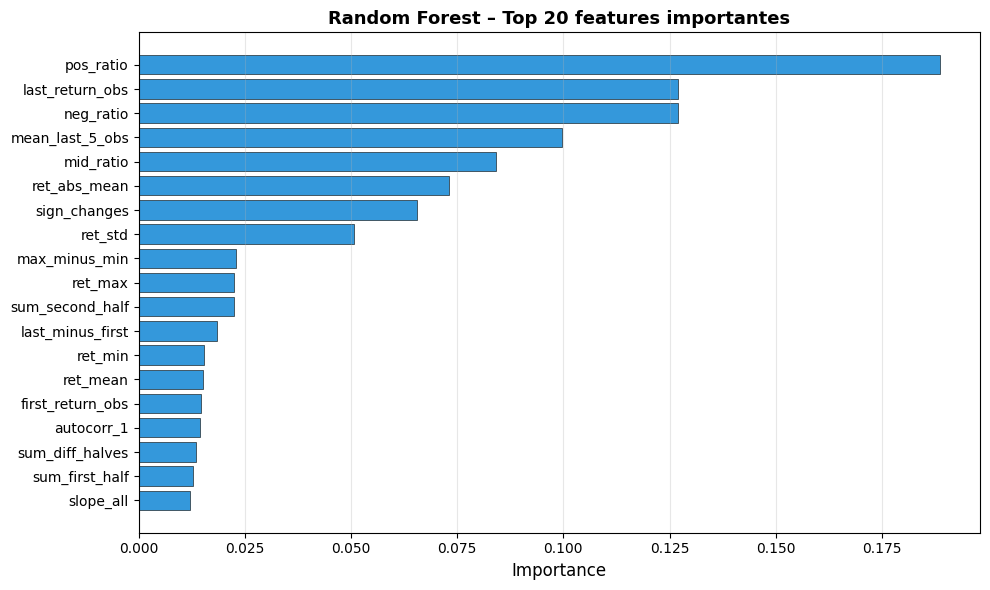

         feature  importance
       pos_ratio    0.188678
 last_return_obs    0.127101
       neg_ratio    0.126938
 mean_last_5_obs    0.099633
       mid_ratio    0.084194
    ret_abs_mean    0.073059
    sign_changes    0.065550
         ret_std    0.050585
   max_minus_min    0.022840
         ret_max    0.022514
 sum_second_half    0.022474
last_minus_first    0.018348
         ret_min    0.015473
        ret_mean    0.015224
first_return_obs    0.014699
      autocorr_1    0.014374
 sum_diff_halves    0.013427
  sum_first_half    0.012730
       slope_all    0.012159


In [39]:
# ─────────────────────────────────────────────────────────────
# 7.1 Feature importance – Random Forest et HGB (permutation)
# ─────────────────────────────────────────────────────────────
def infer_feature_names(reference_X):
    if isinstance(reference_X, pd.DataFrame):
        return reference_X.columns.tolist()
    return [f'feature_{i}' for i in range(reference_X.shape[1])]


def plot_feature_importance_from_values(values, feature_names, title, top_n=20, color='#3498db'):
    values = np.asarray(values)
    idx = np.argsort(values)[::-1][:top_n]
    fig, ax = plt.subplots(figsize=(10, 6))
    ax.barh([feature_names[i] for i in idx][::-1], values[idx][::-1], color=color,
            edgecolor='black', linewidth=0.4)
    ax.set_xlabel('Importance', fontsize=12)
    ax.set_title(title, fontsize=13, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='x')
    plt.tight_layout()
    plt.show()
    return pd.DataFrame({'feature': feature_names, 'importance': values}).sort_values('importance', ascending=False).head(top_n)

feature_names_model = infer_feature_names(X_train)

print('=== Random Forest – Feature Importance ===')
imp_rf = plot_feature_importance_from_values(
    best_rf.feature_importances_,
    feature_names_model,
    'Random Forest – Top 20 features importantes',
    color='#3498db'
)
print(imp_rf.to_string(index=False))


=== Hist Gradient Boosting – Permutation importance ===


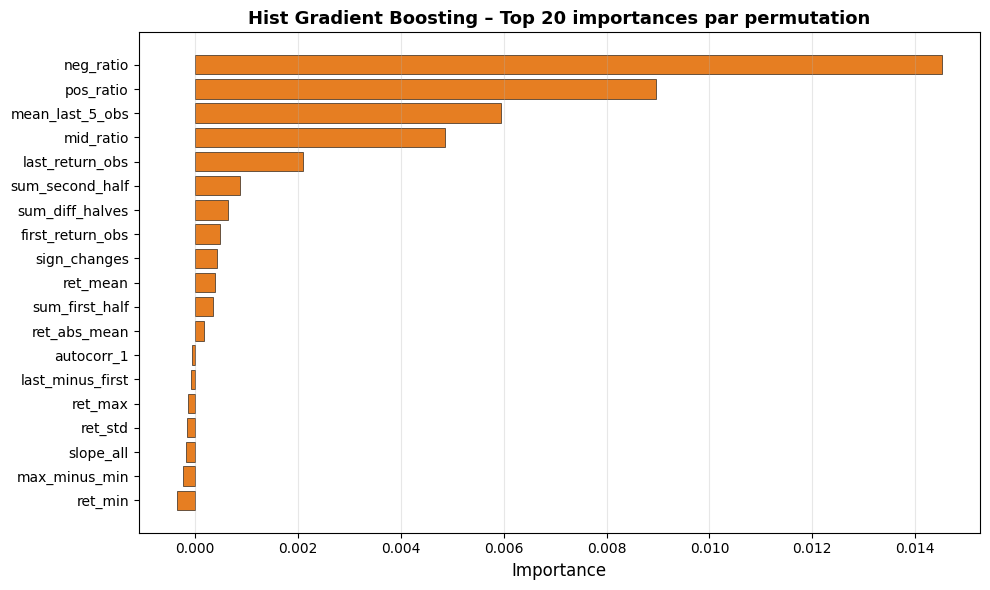

         feature  importance
       neg_ratio    0.014520
       pos_ratio    0.008960
 mean_last_5_obs    0.005943
       mid_ratio    0.004850
 last_return_obs    0.002090
 sum_second_half    0.000867
 sum_diff_halves    0.000640
first_return_obs    0.000483
    sign_changes    0.000417
        ret_mean    0.000377
  sum_first_half    0.000353
    ret_abs_mean    0.000160
      autocorr_1   -0.000070
last_minus_first   -0.000083
         ret_max   -0.000143
         ret_std   -0.000167
       slope_all   -0.000183
   max_minus_min   -0.000240
         ret_min   -0.000357


In [40]:
print('=== Hist Gradient Boosting – Permutation importance ===')

# Sous-échantillon de validation pour limiter le temps de calcul
n_perm_samples = min(60_000, len(X_val))
if len(X_val) > n_perm_samples:
    perm_idx = np.random.RandomState(42).choice(len(X_val), size=n_perm_samples, replace=False)
    if isinstance(X_val, pd.DataFrame):
        X_val_perm = X_val.iloc[perm_idx]
    else:
        X_val_perm = X_val[perm_idx]

    if isinstance(y_val, pd.Series):
        y_val_perm = y_val.iloc[perm_idx]
    else:
        y_val_perm = y_val[perm_idx]
else:
    X_val_perm = X_val
    y_val_perm = y_val

perm_hgb = permutation_importance(
    best_hgb,
    X_val_perm,
    y_val_perm,
    n_repeats=5,
    random_state=42,
    n_jobs=-1
)

imp_hgb = plot_feature_importance_from_values(
    perm_hgb.importances_mean,
    feature_names_model,
    'Hist Gradient Boosting – Top 20 importances par permutation',
    color='#e67e22'
)
print(imp_hgb.to_string(index=False))


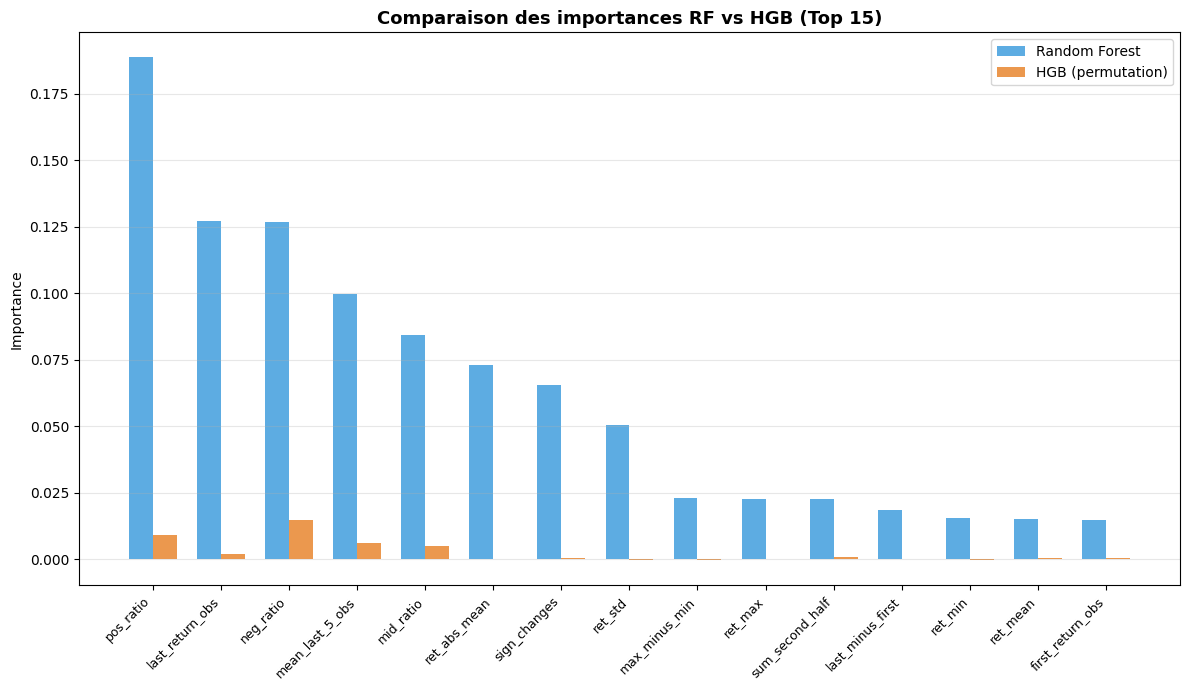

In [41]:
# ─────────────────────────────────────────────────────────────
# 7.2 Comparaison de l'importance entre RF et HGB
# ─────────────────────────────────────────────────────────────
imp_compare = pd.DataFrame({
    'feature': feature_names_model,
    'RF': best_rf.feature_importances_,
    'HGB_perm': perm_hgb.importances_mean
}).set_index('feature').sort_values('RF', ascending=False).head(15)

fig, ax = plt.subplots(figsize=(12, 7))
x = np.arange(len(imp_compare))
width = 0.35
ax.bar(x - width / 2, imp_compare['RF'], width, label='Random Forest', color='#3498db', alpha=0.8)
ax.bar(x + width / 2, imp_compare['HGB_perm'], width, label='HGB (permutation)', color='#e67e22', alpha=0.8)
ax.set_xticks(x)
ax.set_xticklabels(imp_compare.index, rotation=45, ha='right', fontsize=9)
ax.set_title('Comparaison des importances RF vs HGB (Top 15)', fontsize=13, fontweight='bold')
ax.set_ylabel('Importance')
ax.legend()
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


### 7.3 Analyse croisée des importances (sans SHAP)


In [42]:
# ─────────────────────────────────────────────────────────────
# 7.3 Top features communes RF / HGB
# ─────────────────────────────────────────────────────────────
top_k = 20

rf_ranked = pd.Series(best_rf.feature_importances_, index=feature_names_model).sort_values(ascending=False)
hgb_ranked = pd.Series(perm_hgb.importances_mean, index=feature_names_model).sort_values(ascending=False)

common_top_features = list(set(rf_ranked.head(top_k).index).intersection(set(hgb_ranked.head(top_k).index)))
common_top_features = sorted(common_top_features, key=lambda f: (rf_ranked[f] + hgb_ranked[f]), reverse=True)

common_df = pd.DataFrame({
    'feature': common_top_features,
    'RF_importance': [rf_ranked[f] for f in common_top_features],
    'HGB_perm_importance': [hgb_ranked[f] for f in common_top_features]
})

print(f'Nombre de features communes dans les top {top_k}: {len(common_top_features)}')
print(common_df.head(20).to_string(index=False))


Nombre de features communes dans les top 20: 19
         feature  RF_importance  HGB_perm_importance
       pos_ratio       0.188678             0.008960
       neg_ratio       0.126938             0.014520
 last_return_obs       0.127101             0.002090
 mean_last_5_obs       0.099633             0.005943
       mid_ratio       0.084194             0.004850
    ret_abs_mean       0.073059             0.000160
    sign_changes       0.065550             0.000417
         ret_std       0.050585            -0.000167
 sum_second_half       0.022474             0.000867
   max_minus_min       0.022840            -0.000240
         ret_max       0.022514            -0.000143
last_minus_first       0.018348            -0.000083
        ret_mean       0.015224             0.000377
first_return_obs       0.014699             0.000483
         ret_min       0.015473            -0.000357
      autocorr_1       0.014374            -0.000070
 sum_diff_halves       0.013427             0.00064

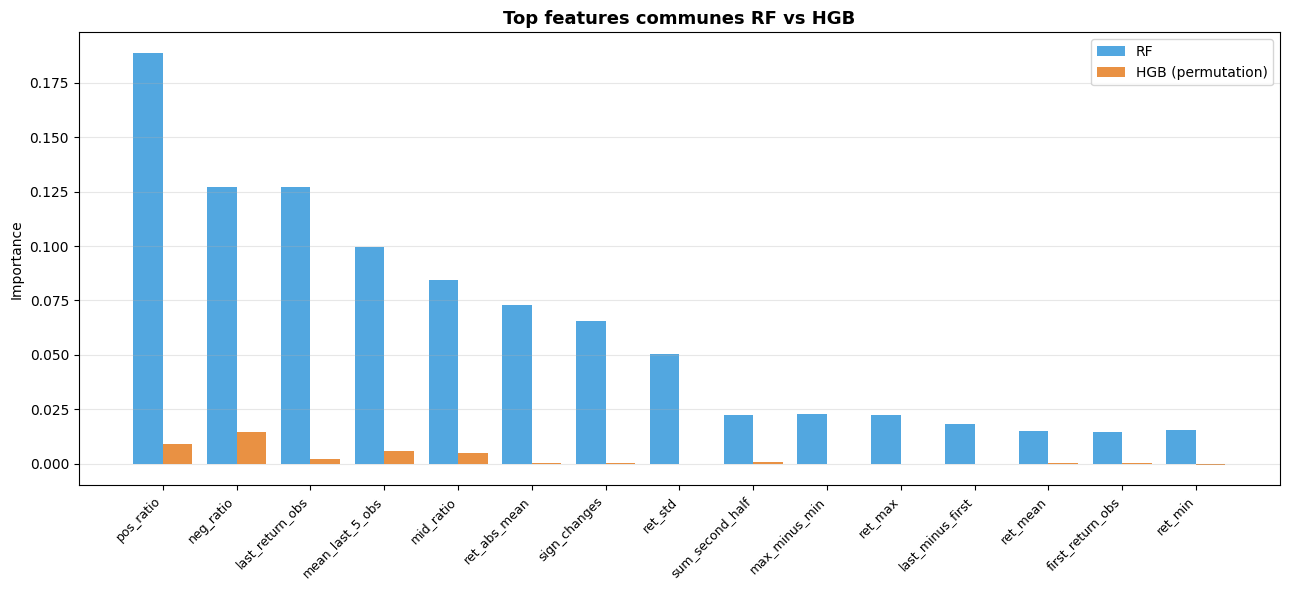

In [43]:
# ─────────────────────────────────────────────────────────────
# Visualisation: importances comparées sur features communes
# ─────────────────────────────────────────────────────────────
if len(common_df) > 0:
    plot_df = common_df.head(15).copy()
    x = np.arange(len(plot_df))
    width = 0.4

    fig, ax = plt.subplots(figsize=(13, 6))
    ax.bar(x - width / 2, plot_df['RF_importance'], width, label='RF', color='#3498db', alpha=0.85)
    ax.bar(x + width / 2, plot_df['HGB_perm_importance'], width, label='HGB (permutation)', color='#e67e22', alpha=0.85)

    ax.set_xticks(x)
    ax.set_xticklabels(plot_df['feature'], rotation=45, ha='right', fontsize=9)
    ax.set_ylabel('Importance')
    ax.set_title('Top features communes RF vs HGB', fontsize=13, fontweight='bold')
    ax.legend()
    ax.grid(True, alpha=0.3, axis='y')
    plt.tight_layout()
    plt.show()


Corrélation RF vs HGB (importances): 0.7774


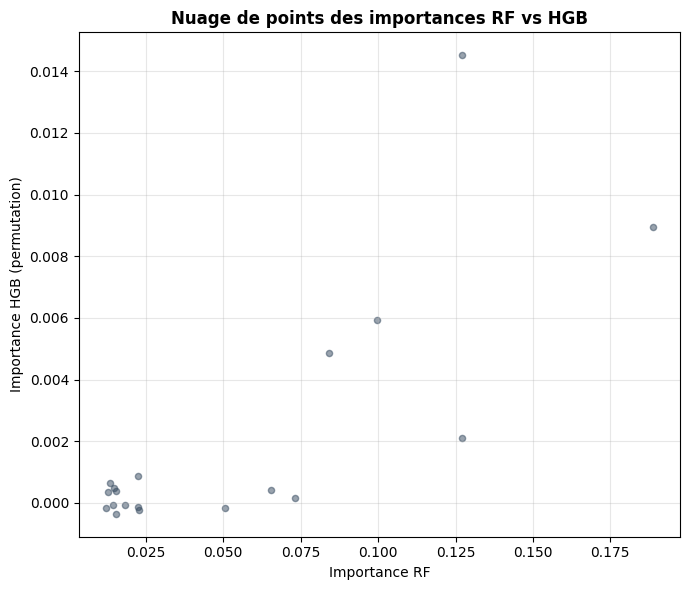

In [44]:
# ─────────────────────────────────────────────────────────────
# Corrélation des importances RF vs HGB
# ─────────────────────────────────────────────────────────────
importance_compare_full = pd.DataFrame({
    'feature': feature_names_model,
    'RF_importance': best_rf.feature_importances_,
    'HGB_perm_importance': perm_hgb.importances_mean
})

corr_importances = importance_compare_full[['RF_importance', 'HGB_perm_importance']].corr().iloc[0, 1]
print(f'Corrélation RF vs HGB (importances): {corr_importances:.4f}')

fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(
    importance_compare_full['RF_importance'],
    importance_compare_full['HGB_perm_importance'],
    alpha=0.5,
    s=20,
    color='#34495e'
)
ax.set_xlabel('Importance RF')
ax.set_ylabel('Importance HGB (permutation)')
ax.set_title('Nuage de points des importances RF vs HGB', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


Variables nécessaires pour 90% d'importance cumulée (RF): 12
Variables nécessaires pour 95% d'importance cumulée (RF): 16


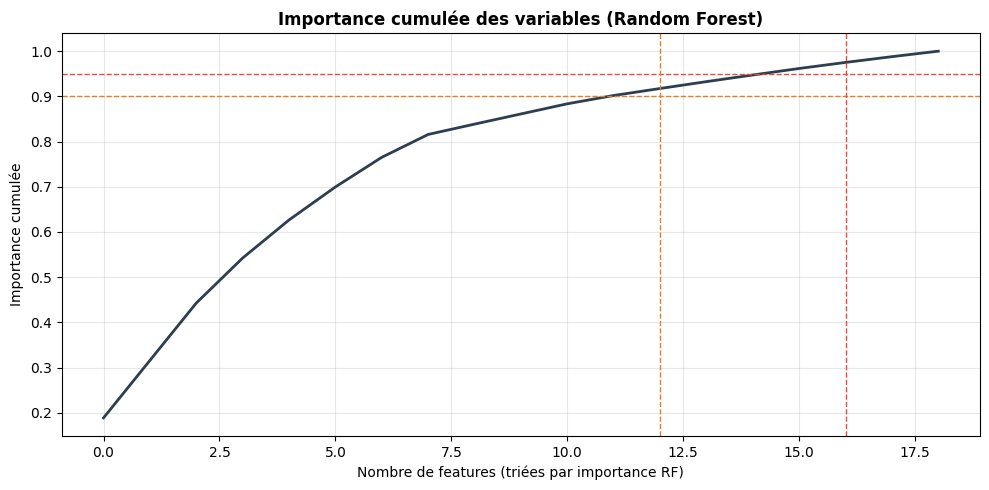

In [46]:
# ─────────────────────────────────────────────────────────────
# Importance cumulée (RF): combien de variables expliquent l'essentiel
# ─────────────────────────────────────────────────────────────
rf_importance_sorted = np.sort(best_rf.feature_importances_)[::-1]
rf_cumulative_importance = np.cumsum(rf_importance_sorted)

threshold_90 = int(np.searchsorted(rf_cumulative_importance, 0.9) + 1)
threshold_95 = int(np.searchsorted(rf_cumulative_importance, 0.95) + 1)

print(f"Variables nécessaires pour 90% d'importance cumulée (RF): {threshold_90}")
print(f"Variables nécessaires pour 95% d'importance cumulée (RF): {threshold_95}")

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(rf_cumulative_importance, color='#2c3e50', linewidth=2)
ax.axhline(0.9, color='#e67e22', linestyle='--', linewidth=1)
ax.axhline(0.95, color='#e74c3c', linestyle='--', linewidth=1)
ax.axvline(threshold_90, color='#e67e22', linestyle='--', linewidth=1)
ax.axvline(threshold_95, color='#e74c3c', linestyle='--', linewidth=1)
ax.set_xlabel('Nombre de features (triées par importance RF)')
ax.set_ylabel('Importance cumulée')
ax.set_title('Importance cumulée des variables (Random Forest)', fontsize=12, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


## 8. Comparaison finale des performances et interprétation

### 8.1 Tableau récapitulatif


In [49]:
# ─────────────────────────────────────────────────────────────
# 8.1 Récapitulatif de toutes les performances
# ─────────────────────────────────────────────────────────────
results = {
    'Logistic Regression (base)': {
        'acc_train': acc_train_logreg_base,
        'acc_val': acc_val_logreg_base,
        'bacc_val': np.nan,
        'f1_val': np.nan,
    },
    'Logistic Regression (opt)': {
        'acc_train': acc_train_logreg,
        'acc_val': acc_logreg_best,
        'bacc_val': bacc_logreg_best,
        'f1_val': f1_logreg_best,
    },
    'Logistic + clusters (best)': {
        'acc_train': results_logreg_cluster['acc_train'],
        'acc_val': results_logreg_cluster['acc_val'],
        'bacc_val': results_logreg_cluster['bacc_val'],
        'f1_val': results_logreg_cluster['f1_val'],
    },
    'Random Forest (base)': {
        'acc_train': acc_train_rf,
        'acc_val': acc_rf,
        'bacc_val': bacc_rf,
        'f1_val': f1_rf,
    },
    'Random Forest (opt)': {
        'acc_train': acc_train_best_rf,
        'acc_val': acc_val_best_rf,
        'bacc_val': bacc_val_best_rf,
        'f1_val': f1_val_best_rf,
    },
    'HGB (base)': {
        'acc_train': acc_train_hgb,
        'acc_val': acc_val_hgb,
        'bacc_val': bacc_val_hgb,
        'f1_val': f1_val_hgb,
    },
    'HGB (opt)': {
        'acc_train': acc_train_best_hgb,
        'acc_val': acc_best_hgb,
        'bacc_val': bacc_best_hgb,
        'f1_val': f1_best_hgb,
    },
}

results_df = pd.DataFrame(results).T
results_df.columns = ['Accuracy Train', 'Accuracy Val', 'Balanced Accuracy Val', 'Macro-F1 Val']
results_df = results_df.sort_values('Accuracy Val', ascending=False)

print('=' * 80)
print('RÉCAPITULATIF DES PERFORMANCES')
print('=' * 80)
print(results_df.round(4).to_string())


RÉCAPITULATIF DES PERFORMANCES
                            Accuracy Train  Accuracy Val  Balanced Accuracy Val  Macro-F1 Val
Random Forest (opt)                 0.5188        0.4716                 0.4339        0.4138
HGB (opt)                              NaN        0.4713                    NaN           NaN
HGB (base)                          0.4863        0.4709                 0.4334        0.4166
Logistic + clusters (best)          0.4607        0.4617                 0.4386        0.4335
Logistic Regression (opt)           0.4578        0.4589                    NaN           NaN
Random Forest (base)                0.4643        0.4571                    NaN           NaN


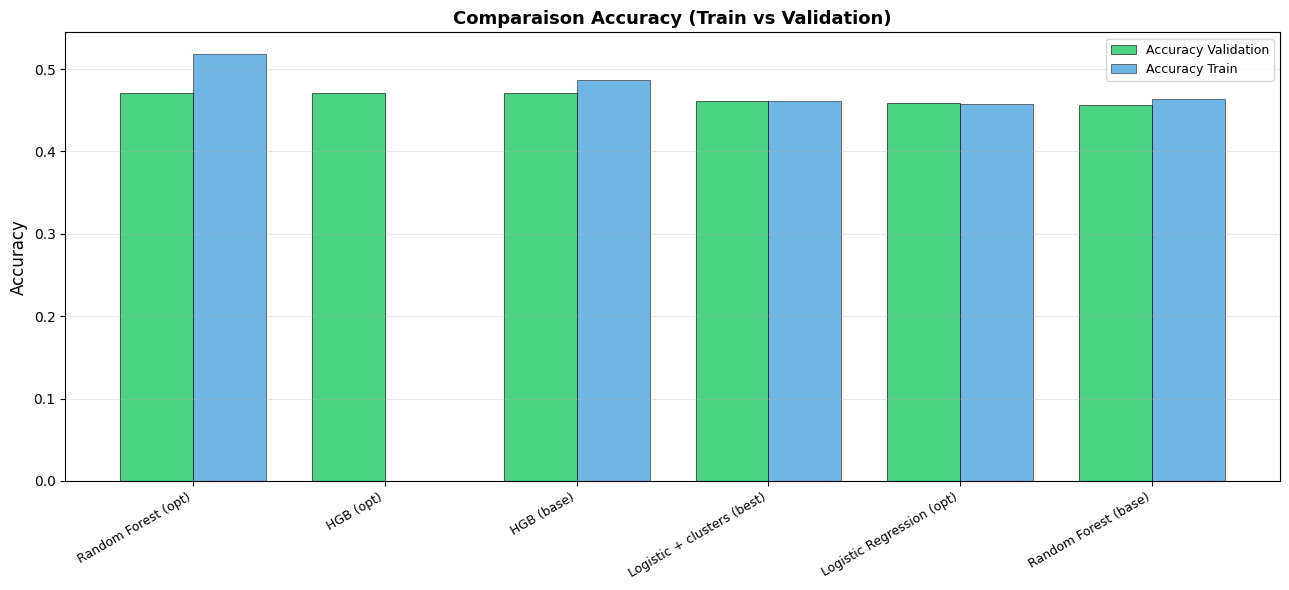

In [50]:
# ─────────────────────────────────────────────────────────────
# 8.1 Visualisation: ranking Accuracy train/val
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(13, 6))

model_names = results_df.index.tolist()
acc_val_values = results_df['Accuracy Val'].values
acc_train_values = results_df['Accuracy Train'].values

x = np.arange(len(model_names))
bar_width = 0.38

ax.bar(x - bar_width / 2, acc_val_values, bar_width, label='Accuracy Validation',
       color='#2ecc71', alpha=0.85, edgecolor='black', linewidth=0.5)
ax.bar(x + bar_width / 2, acc_train_values, bar_width, label='Accuracy Train',
       color='#3498db', alpha=0.70, edgecolor='black', linewidth=0.5)

ax.set_xticks(x)
ax.set_xticklabels(model_names, rotation=30, ha='right', fontsize=9)
ax.set_ylabel('Accuracy', fontsize=12)
ax.set_title('Comparaison Accuracy (Train vs Validation)', fontsize=13, fontweight='bold')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()


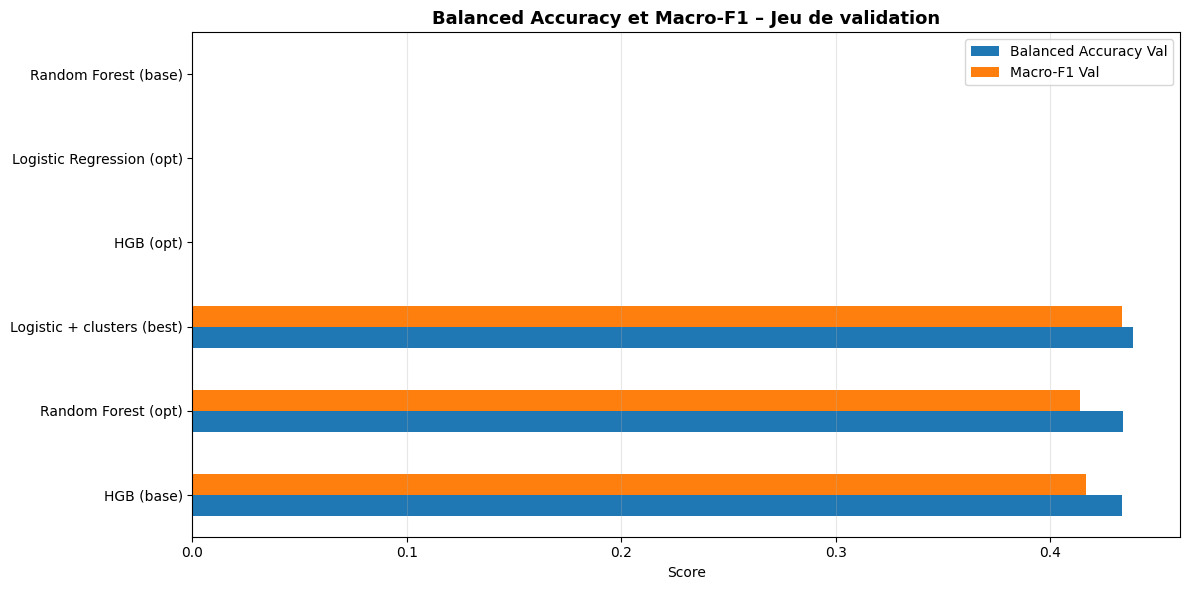

NameError: name 'sns' is not defined

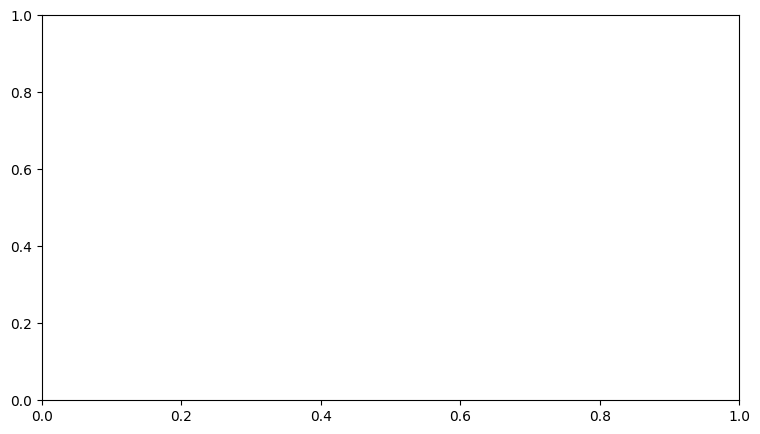

In [51]:
# ─────────────────────────────────────────────────────────────
# 8.2 Balanced accuracy et Macro-F1 comparées + heatmap
# ─────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 6))
results_df[['Balanced Accuracy Val', 'Macro-F1 Val']].sort_values('Balanced Accuracy Val').plot(
    kind='barh', ax=ax
)
ax.set_title('Balanced Accuracy et Macro-F1 – Jeu de validation', fontsize=13, fontweight='bold')
ax.set_xlabel('Score')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

# Heatmap des métriques de validation
validation_metrics = results_df[['Accuracy Val', 'Balanced Accuracy Val', 'Macro-F1 Val']]
fig, ax = plt.subplots(figsize=(9, 5))
sns.heatmap(validation_metrics, annot=True, fmt='.4f', cmap='YlGnBu', cbar=True, ax=ax)
ax.set_title('Heatmap des performances validation', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()


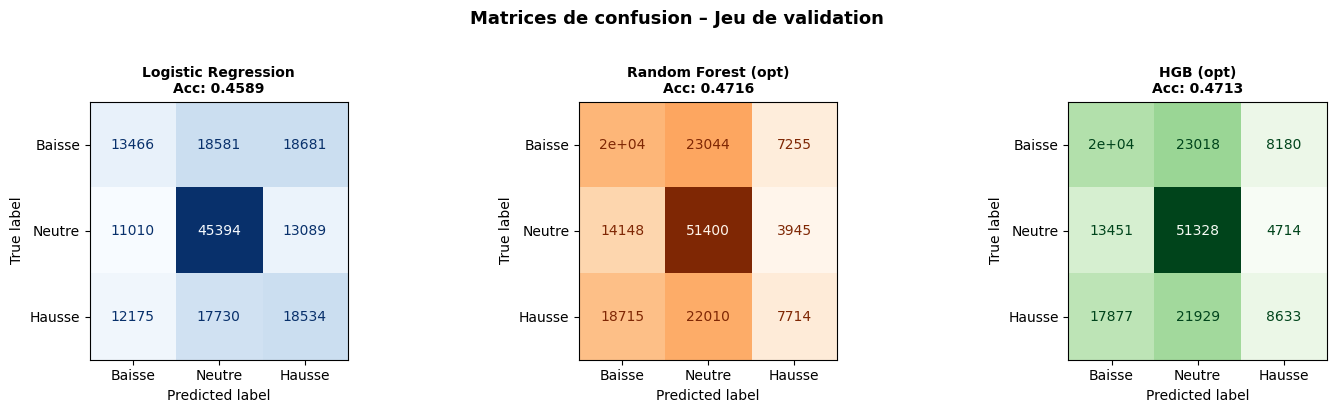

In [52]:
# ─────────────────────────────────────────────────────────────
# 8.3 Matrices de confusion des meilleurs modèles
# ─────────────────────────────────────────────────────────────
comparison_models = {
    'Logistic Regression': (best_logreg.predict(val_feats), 'Blues'),
    'Random Forest (opt)': (best_rf.predict(X_val), 'Oranges'),
    'HGB (opt)': (best_hgb.predict(X_val), 'Greens'),
}

fig, axes = plt.subplots(1, len(comparison_models), figsize=(5 * len(comparison_models), 4))
if len(comparison_models) == 1:
    axes = [axes]

for ax, (name, (y_pred, cmap)) in zip(axes, comparison_models.items()):
    cm = confusion_matrix(y_val, y_pred, labels=[-1, 0, 1])
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Baisse', 'Neutre', 'Hausse'])
    disp.plot(ax=ax, cmap=cmap, colorbar=False)
    acc = accuracy_score(y_val, y_pred)
    ax.set_title(f'{name}\nAcc: {acc:.4f}', fontsize=10, fontweight='bold')

plt.suptitle('Matrices de confusion – Jeu de validation', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


### 8.3 Sélection du modèle final et prédictions sur le jeu de test

On sélectionne le meilleur modèle selon l'accuracy de validation et on génère les prédictions finales pour la soumission. Pour le challenge 84, la colonne à soumettre est **`reod`**.

In [53]:
# ─────────────────────────────────────────────────────────────
# 8.4 Génération des prédictions pour la soumission
# ─────────────────────────────────────────────────────────────
print('Préparation du jeu de test final...')

# Features de base
base_test_feats = build_features(X_test_challenge)
expected_feature_names = X_train.columns.tolist()

for col in expected_feature_names:
    if col not in base_test_feats.columns:
        base_test_feats[col] = 0

base_test_feats = base_test_feats[expected_feature_names].fillna(0)
print(f'Jeu de test (features de base) : {base_test_feats.shape}')

# Features enrichies cluster pour le modèle logistique + clusters
X_test_cluster = X_test_challenge[R_COLS].fillna(0).values
X_test_cluster_scaled = scaler_clust.transform(X_test_cluster)
test_cluster_labels = kmeans_final.predict(X_test_cluster_scaled)
test_cluster_distances = kmeans_final.transform(X_test_cluster_scaled)

def build_logreg_cluster_test_matrix(base_features_df):
    test_cluster_onehot = pd.get_dummies(pd.Series(test_cluster_labels, name='cluster_label'), prefix='cluster')
    distance_cols = [f'cluster_distance_{i}' for i in range(test_cluster_distances.shape[1])]
    test_distance_df = pd.DataFrame(test_cluster_distances, columns=distance_cols)

    candidate_df = pd.concat([
        base_features_df.reset_index(drop=True),
        test_cluster_onehot.reset_index(drop=True),
        test_distance_df.reset_index(drop=True)
    ], axis=1)

    expected_cols = list(best_logreg_cluster.named_steps['imputer'].feature_names_in_)
    return candidate_df.reindex(columns=expected_cols, fill_value=0)

cluster_test_feats = build_logreg_cluster_test_matrix(base_test_feats)

# Sélection automatique du meilleur modèle selon Accuracy Val
best_model_name = results_df.index[0]

model_lookup = {
    'Logistic Regression (base)': (logreg, base_test_feats),
    'Logistic Regression (opt)': (best_logreg, base_test_feats),
    'Logistic + clusters (best)': (best_logreg_cluster, cluster_test_feats),
    'Random Forest (base)': (rf_base, base_test_feats),
    'Random Forest (opt)': (best_rf, base_test_feats),
    'HGB (base)': (hgb, base_test_feats),
    'HGB (opt)': (best_hgb, base_test_feats),
}

best_model_final, X_test_for_best = model_lookup[best_model_name]
y_pred_final = best_model_final.predict(X_test_for_best)

print(f'Modèle final sélectionné : {best_model_name}')
print(f'Prédictions générées : {len(y_pred_final)}')
print(f'Distribution des prédictions : {pd.Series(y_pred_final).value_counts().sort_index().to_dict()}')

submission = pd.DataFrame({
    'ID': X_test_challenge['ID'],
    'reod': y_pred_final
})
submission.to_csv('output_test_predictions.csv', index=False)

print('')
print("✓ Fichier 'output_test_predictions.csv' généré (format ID,reod).")
print(submission.head())


Préparation du jeu de test final...
Jeu de test final : (885799, 19)
Modèle final sélectionné : Random Forest (opt)
Prédictions générées : 885799
Distribution des prédictions : {-1: 395977, 0: 232697, 1: 257125}

✓ Fichier 'output_test_predictions.csv' généré (format ID,reod).
        ID  reod
0  1000000    -1
1  1000001    -1
2  1000002    -1
3  1000003     1
4  1000004     0


In [54]:
# ─────────────────────────────────────────────────────────────
# 8.5 Export dédié HGB (opt)
# ─────────────────────────────────────────────────────────────
print('Génération de prediction_hgb.csv avec HGB (opt)...')

try:
    test_feats_hgb = base_test_feats.copy()
except NameError:
    test_feats_hgb = build_features(X_test_challenge)
    expected_feature_names = X_train.columns.tolist()
    for col in expected_feature_names:
        if col not in test_feats_hgb.columns:
            test_feats_hgb[col] = 0
    test_feats_hgb = test_feats_hgb[expected_feature_names].fillna(0)

y_pred_hgb_test = best_hgb.predict(test_feats_hgb)

prediction_hgb = pd.DataFrame({
    'ID': X_test_challenge['ID'],
    'reod': y_pred_hgb_test
})
prediction_hgb.to_csv('prediction_hgb.csv', index=False)

print("✓ Fichier 'prediction_hgb.csv' généré (format ID,reod).")
print(prediction_hgb.head())


Génération de prediction_hgb.csv avec HGB (opt)...
✓ Fichier 'prediction_hgb.csv' généré (format ID,reod).
        ID  reod
0  1000000    -1
1  1000001    -1
2  1000002     1
3  1000003     1
4  1000004     0


## 9. Conclusion et interprétation des résultats

### 9.1 Synthèse des performances

[À remplir après exécution – voici le cadre d'analyse :]

| Modèle | Accuracy Val | Commentaire |
|---|---|---|
| DummyClassifier | ? | Baseline triviale, classe majoritaire |
| Régression Logistique multinomiale | ? | Modèle linéaire robuste et interprétable |
| K-Means (naïf) | ? | Non supervisé, sert surtout à caractériser des régimes intraday |
| Random Forest (opt) | ? | Ensembliste bagging |
| HGB (opt) | ? | Boosting efficace sur variables tabulaires |
| LightGBM | ? | Optionnel si disponible |

### 9.2 Enseignements principaux

1. **Le challenge 84 est bien un problème CFM à 3 classes** (`reod`) et non un problème binaire avec cible `RET`.
2. **Le bon niveau d'analyse est intraday** : les signaux exploitables proviennent de la forme de la trajectoire `r0...r52` et non de rendements journaliers `RET_1...RET_20`.
3. **Les features de pente, de volatilité intraday et de dynamique sur la fin de matinée** peuvent porter une partie du signal.
4. **Le clustering** aide à détecter des profils de trajectoires, même si son pouvoir prédictif direct reste limité.
5. **Les méthodes ensemblistes** sont souvent mieux adaptées que les modèles linéaires à ce type de structure non linéaire.

### 9.3 Pistes d'amélioration

- Ajouter des features de trajectoire plus fines : autocorrélations, ruptures, temps de retour à zéro, drawdown intraday ;
- Tester des modèles séquentiels (1D-CNN, LSTM, Transformer léger) sur la suite `r0...r52` ;
- Comparer une validation bloquée stricte par périodes plus longues ;
- Introduire des agrégations plus fines par `day` et `equity` si cela améliore la généralisation.